In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm


warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
import os
os.makedirs('images/open_transaction', exist_ok=True)


In [ ]:
# Load dataset
file_path = '..\processed data\Open Transaction Data Cleaned.xlsx'

# ensure path exists
import os
if not os.path.exists(file_path):
    raise FileNotFoundError(f"Data file not found: {file_path}")
df = pd.read_excel(file_path)

print(f'Dataset loaded successfully.')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')

Dataset loaded successfully.
Shape: 416,627 rows x 13 columns


In [10]:
df

,Property Type,District,Mukim,Scheme Name/Area,Road Name,Transaction Date,Tenure,Land,Area,Unit Level,Price,Year,Month
0,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Bdr Masjid Tanah,TMN BUKIT INDAH FASA 2,JLN BUKIT INDAH 6,2024-03-01,Freehold,374.00,106.0,,470000,2024,3
1,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN BELIMBING HARMONI,JLN BELIMBING HARMONI,2023-05-01,Leasehold,234.00,67.0,,483000,2023,5
2,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN VISTA BELIMBING,JALAN DURIAN TUNGGAL-ALOR GAJAH,2021-04-01,Freehold,268.00,118.0,,359000,2021,4
3,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN VISTA BELIMBING,JALAN DURIAN TUNGGAL-ALOR GAJAH,2021-04-01,Freehold,268.00,118.0,,435000,2021,4
4,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN VISTA BELIMBING,JALAN DURIAN TUNGGAL-ALOR GAJAH,2021-04-01,Freehold,297.00,118.0,,373000,2021,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
416622,Town House,Timur Laut,Tanjung Tokong,TANJONG VILLA,,2022-08-01,Freehold,103.00,NaN,1,850000,2022,8
416623,Town House,Timur Laut,Tanjung Tokong,TANJONG VILLA,,2024-02-01,Freehold,174.00,NaN,1,1110000,2024,2
416624,Town House,Timur Laut,Tanjung Tokong,VILLA BUNGA TELANG,,2023-07-01,Freehold,83.00,NaN,3,540000,2023,7
416625,Town House,Timur Laut,Tanjung Tokong,VILLA BUNGA TELANG,,2025-01-01,Freehold,83.00,NaN,3,525000,2025,1


In [11]:
cols_ = ['Area', 'Price', 'Land']
for col in cols_:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# dummy‑encode the categorical predictors
df_dummy = pd.get_dummies(df,
                          columns=['Property Type', 'District', 'Tenure'],
                          drop_first=True,
                          dtype=int)

# 2. define the feature list
features = ['Land', 'Area'] + [
    col for col in df_dummy.columns
    if ('Property Type' in col or 'District' in col or 'Tenure' in col)
]

# 3. clean the data (drop rows with missing values)
df_cleaned = df_dummy.dropna(subset=['Price'] + features)

# 4. X and y
X = df_cleaned[features]
y = np.log(df_cleaned['Price']) #log to get percentage effects and reduce skewness

# 5. add constant
X = sm.add_constant(X)

# 6. fit and show summary
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.653
Model:                            OLS   Adj. R-squared:                  0.653
Method:                 Least Squares   F-statistic:                     4298.
Date:                Sat, 06 Jun 2026   Prob (F-statistic):               0.00
Time:                        01:34:36   Log-Likelihood:            -1.5162e+05
No. Observations:              308886   AIC:                         3.035e+05
Df Residuals:                  308750   BIC:                         3.050e+05
Df Model:                         135                                         
Covariance Type:            nonrobust                                         
                                                   coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

In [12]:
df_dummy['log_Land'] = np.where(df_dummy['Land'] > 0, np.log(df_dummy['Land']), np.nan)
df_dummy['log_Area'] = np.where(df_dummy['Area'] > 0, np.log(df_dummy['Area']), np.nan)

features = ['log_Land', 'log_Area'] + [
    col for col in df_dummy.columns
    if ('Property Type' in col or 'District' in col or 'Tenure' in col)
]

# 3. clean the data (drop rows with missing values)
df_cleaned = df_dummy.dropna(subset=['Price'] + features)

# 4. X and y
X = df_cleaned[features]
y = np.log(df_cleaned['Price']) #log to get percentage effects and reduce skewness

# 5. add constant
X = sm.add_constant(X)

# 6. fit and show summary
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.801
Model:                            OLS   Adj. R-squared:                  0.801
Method:                 Least Squares   F-statistic:                     9222.
Date:                Sat, 06 Jun 2026   Prob (F-statistic):               0.00
Time:                        01:36:23   Log-Likelihood:                -65361.
No. Observations:              308865   AIC:                         1.310e+05
Df Residuals:                  308729   BIC:                         1.324e+05
Df Model:                         135                                         
Covariance Type:            nonrobust                                         
                                                   coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

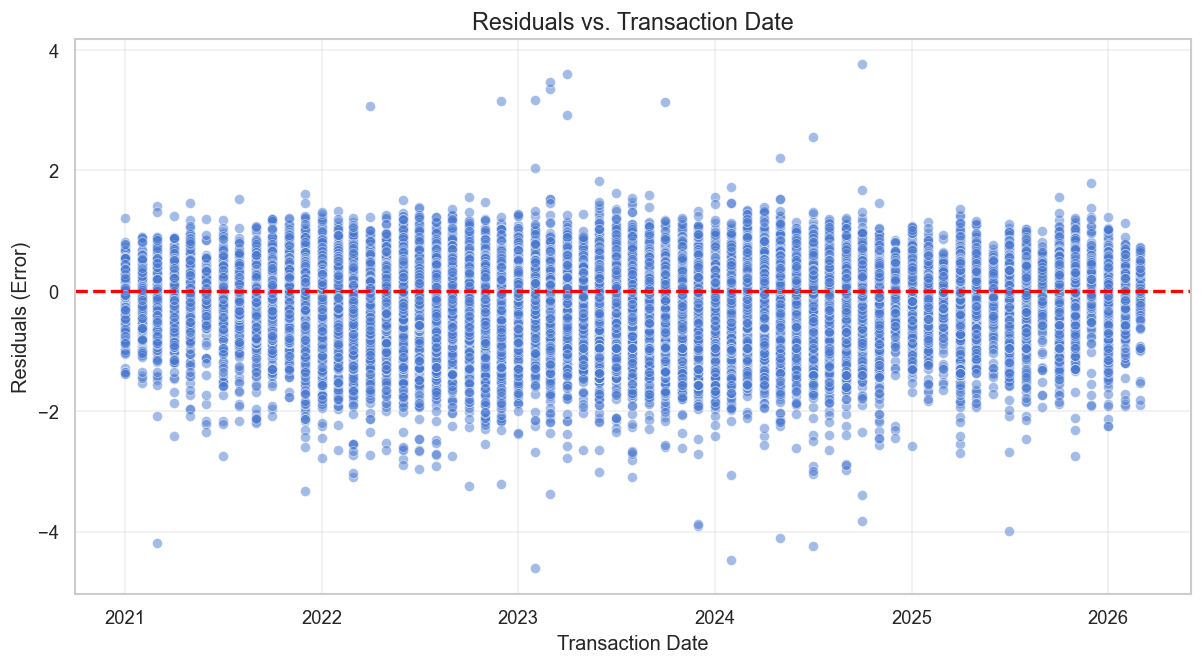

In [13]:
residuals = model.resid

# 2. Match residuals with the corresponding dates
# We use df_cleaned because it matches the rows used in the model
plot_data = pd.DataFrame({
    'Transaction Date': df['Transaction Date'], 
    'Residuals': residuals
})
# 3. Create the plot
plt.figure(figsize=(12, 6))
sns.scatterplot(data=plot_data, x='Transaction Date', y='Residuals', alpha=0.5)

# 4. Add a horizontal line at 0
plt.axhline(0, color='red', linestyle='--', linewidth=2)

# 5. Add Labels and Title
plt.title('Residuals vs. Transaction Date', fontsize=14)
plt.xlabel('Transaction Date')
plt.ylabel('Residuals (Error)')
plt.grid(True, alpha=0.3)

plt.show()

In [ ]:
# 1. Create a DataFrame for VIF results
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns

# 2. Calculate VIF for each feature
vif_data["VIF"] = [variance_inflation_factor(X.values, i) 
                   for i in range(X.shape[1])]

# 3. Display results sorted by VIF
vif_results = vif_data.sort_values(by="VIF", ascending=False)
print(vif_results.to_string())

print('\n' + '='*60)
print('MULTICOLLINEARITY ANALYSIS (VIF - Variance Inflation Factor)')
print('='*60)
print('\nObservation:')
print('VIF values indicate the degree of multicollinearity in the regression model.')
print('Interpretation:')
print('  - VIF = 1: No correlation with other features')
print('  - VIF < 5: Generally acceptable level of multicollinearity')
print('  - VIF > 5-10: Moderate to high multicollinearity (may need attention)')
print('  - VIF > 10: High multicollinearity (should be addressed)')

high_vif = vif_results[vif_results['VIF'] > 5]
if len(high_vif) > 0:
    print(f'\nAlert: {len(high_vif)} variable(s) have VIF > 5:')
    for idx, row in high_vif.iterrows():
        print(f'  - {row["Variable"]}: VIF = {row["VIF"]:.2f}')
    print('\nThese variables may have high correlation with other predictors.')
    print('Consider removing or combining correlated variables if VIF > 10.')
else:
    print('\n✓ All variables have acceptable VIF values (< 5).')
    print('No significant multicollinearity detected in the model.')


In [14]:
# Remove extreme outliers from the regression dataset and re‑fit the model

# 1. Calculate Z‑scores for the log residuals
resid_mean = model.resid.mean()
resid_std = model.resid.std()
z_scores = (model.resid - resid_mean) / resid_std

# 2. Filter the dataframe to keep only points within 3 standard deviations
# This will remove any extreme high‑end outliers
from numpy import abs as np_abs

df_no_outliers = df_cleaned[np_abs(z_scores) < 3].copy()
print(f"Rows removed as outliers: {len(df_cleaned) - len(df_no_outliers)}")

# 3. Re-run the regression on this cleaner dataset
y_final = np.log(df_no_outliers['Price'])
# use log versions for Land and Area in the final feature set
features_final = [f for f in features if f not in ('Land', 'Area')]
for v in ('log_Land', 'log_Area'):
    if v in df_no_outliers.columns and v not in features_final:
        features_final.insert(0, v)

X_final = sm.add_constant(df_no_outliers[features_final])
model_final = sm.OLS(y_final, X_final).fit()
robust_results = model_final.get_robustcov_results(cov_type='HAC', maxlags=1)
print(robust_results.summary())

print('\nObservation: After excluding observations with residuals beyond ±3 standard deviations, the revised model is estimated on a cleaner sample. Robust (HAC) standard errors are used to mitigate heteroskedasticity/serial correlation. Compare coefficient estimates and fit statistics with the original regression to understand the influence of extreme outliers.')


Rows removed as outliers: 4543
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.843
Model:                            OLS   Adj. R-squared:                  0.843
Method:                 Least Squares   F-statistic:                     6137.
Date:                Sat, 06 Jun 2026   Prob (F-statistic):               0.00
Time:                        01:37:23   Log-Likelihood:                -10589.
No. Observations:              304322   AIC:                         2.145e+04
Df Residuals:                  304186   BIC:                         2.290e+04
Df Model:                         135                                         
Covariance Type:                  HAC                                         
                                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------

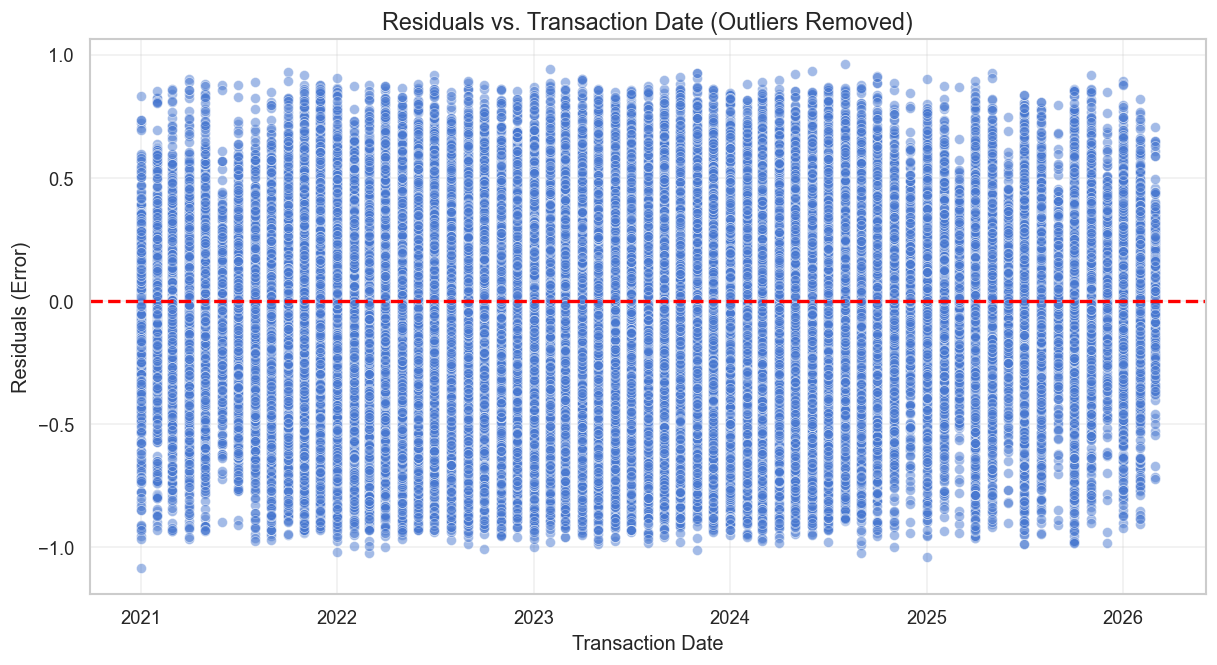

Observation: With extreme cases removed, residuals are more tightly clustered around zero and outliers beyond ±6 have disappeared, indicating improved model stability.


In [15]:
# Plot residuals for the model trained on outlier-removed data
resid_final = model_final.resid
plot_data2 = pd.DataFrame({
    'Transaction Date': df_no_outliers['Transaction Date'],
    'Residuals': resid_final
})

plt.figure(figsize=(12, 6))
sns.scatterplot(data=plot_data2, x='Transaction Date', y='Residuals', alpha=0.5)
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.title('Residuals vs. Transaction Date (Outliers Removed)', fontsize=14)
plt.xlabel('Transaction Date')
plt.ylabel('Residuals (Error)')
plt.grid(True, alpha=0.3)
plt.show()

print('Observation: With extreme cases removed, residuals are more tightly clustered around zero and outliers beyond ±6 have disappeared, indicating improved model stability.')


In [16]:
# Residual diagnostics for final model
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

# Calculate Durbin-Watson for serial correlation
dw_stat = durbin_watson(resid_final)
print(f"Durbin-Watson statistic: {dw_stat:.3f}"
      " (values around 2 suggest no serial correlation)")

# Breusch-Pagan test for heteroskedasticity
bp_test = het_breuschpagan(resid_final, X_final)
lm_stat, lm_pvalue, f_stat, f_pvalue = bp_test
print('\nBreusch-Pagan test:')
print(f'  LM statistic = {lm_stat:.3f}, p-value = {lm_pvalue:.3f}')
print(f'  F statistic  = {f_stat:.3f}, p-value = {f_pvalue:.3f}')

print('\nObservation:')
print('  - Durbin-Watson near 2 indicates',
      'no strong evidence of serial correlation.' )
print('  - Breusch-Pagan p-value > 0.05 suggests homoskedastic residuals',
      ' (no heteroskedasticity). If p-value is small, heteroskedasticity exists.')
print('  - Use HAC robust standard errors if heteroskedasticity or serial correlation is detected to ensure valid inference.')


Durbin-Watson statistic: 0.757 (values around 2 suggest no serial correlation)

Breusch-Pagan test:
  LM statistic = 24279.361, p-value = 0.000
  F statistic  = 195.352, p-value = 0.000

Observation:
  - Durbin-Watson near 2 indicates no strong evidence of serial correlation.
  - Breusch-Pagan p-value > 0.05 suggests homoskedastic residuals  (no heteroskedasticity). If p-value is small, heteroskedasticity exists.
  - Use HAC robust standard errors if heteroskedasticity or serial correlation is detected to ensure valid inference.
